# Part 3 — The Temporal Profile of Cross-Mouse Consensus

Resolves cross-mouse consistency at 10 ms resolution across the full
−50 to +370 ms epoch to characterise the two-component temporal structure:
a transient peak near 100 ms followed by decay to a sustained floor. Two
supplementary analyses corroborate the finding with independent measures:
image-ranking stability across epochs, and second-order RSA (consistency
of representational dynamics across mice).

**Depends on:** `responses.h5`, `manifest.json`
**Outputs saved:** `part3_outputs.npz` (consumed by Parts 4 and 8)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon
from scipy.optimize import curve_fit

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')
COL_NS  = 'steelblue'
COL_GR  = 'darkorange'
COL_FIT = 'firebrick'
COL_REF = 'dimgray'


colors  = apply_plot_style()
COL_NS  = colors["COL_NS"]
COL_GR  = colors["COL_GR"]
COL_FIT = colors["COL_FIT"]
COL_REF = colors["COL_REF"]

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES    = manifest['n_images']
SESSION_IDS = manifest['selected_session_ids_visp']

print(f'Sessions: {len(SESSION_IDS)}, Images: {N_IMAGES}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Sessions: 32, Images: 118


In [3]:
print('Loading VISp tensors...')
all_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        all_tensors[sid] = {
            'tensor':    grp['tensor'][:],
            'unit_ids':  grp['unit_ids'][:],
            'image_ids': grp['image_ids'][:],
        }
print(f'Loaded {len(all_tensors)} sessions.')

Loading VISp tensors...
Loaded 32 sessions.


## 3.1 — Early vs. late window comparison

A coarse two-window split establishes that cross-mouse agreement is
concentrated in the later epoch before the finer sliding-window analysis
in 3.2 confirms the transient shape. The 75 ms split separates the early
feedforward epoch (thalamic input arriving ~40–70 ms post-onset) from the
later recurrent/feedback-influenced epoch.

In [4]:
EARLY_WIN = (0.0,  75.0)
LATE_WIN  = (75.0, 250.0)

def consistency_for_window(tensors, sid_list, t_lo, t_hi):
    mats = [window_response(tensors[s]['tensor'], t_lo, t_hi) for s in sid_list]
    sims = compute_similarity_matrices(mats)
    c, _, _ = per_image_consistency(sims)
    return c

c_early = consistency_for_window(all_tensors, SESSION_IDS, *EARLY_WIN)
c_late  = consistency_for_window(all_tensors, SESSION_IDS, *LATE_WIN)

stat_wil, p_wil = wilcoxon(c_early, c_late)
r_el, p_el      = spearmanr(c_early, c_late)

print(f'Early (0–75 ms)   : mean r = {c_early.mean():.3f}')
print(f'Late (75–250 ms)  : mean r = {c_late.mean():.3f}')
print(f'Wilcoxon p = {p_wil:.2e}  (image rankings preserved: r = {r_el:.3f})')

Early (0–75 ms)   : mean r = 0.084
Late (75–250 ms)  : mean r = 0.320
Wilcoxon p = 4.21e-21  (image rankings preserved: r = 0.365)


## 3.2 — Sliding-window temporal profile

25 ms windows stepped at 10 ms increments from −50 to +370 ms. Each window's
response matrices are reconstructed by slicing the binned tensor — no NWB
access required. The pre-stimulus baseline near zero validates the measure.

In [5]:
WINDOW_WIDTH_MS = 25.0
WINDOW_STEP_MS  = 10
SLIDE_START_MS  = -50
SLIDE_END_MS    = 375

window_centers_ms = list(range(SLIDE_START_MS, SLIDE_END_MS, WINDOW_STEP_MS))
sliding_per_image = {}
for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2
    mats = [window_response(all_tensors[s]['tensor'], t_lo, t_hi)
            for s in SESSION_IDS]
    sims = compute_similarity_matrices(mats)
    c, _, _ = per_image_consistency(sims)
    sliding_per_image[t_ms] = c

times_ms = sorted(sliding_per_image.keys())
mean_c   = np.array([sliding_per_image[t].mean() for t in times_ms])
times_arr = np.array(times_ms, dtype=float)

pre_mask = times_arr < 0
baseline = mean_c[pre_mask].mean()
peak_t   = times_ms[np.argmax(mean_c)]
peak_c   = mean_c.max()
onset_t  = next((t for t, c in zip(times_ms, mean_c)
                 if t >= 0 and c > max(2 * baseline, 0.05)), None)

SUSTAINED_LO, SUSTAINED_HI = 220, 250
sus_mask = (times_arr >= SUSTAINED_LO) & (times_arr <= SUSTAINED_HI)
sustained_floor = mean_c[sus_mask].mean()
sustained_sd    = mean_c[sus_mask].std()

print(f'\nBaseline : {baseline:.4f}')
print(f'Onset    : {onset_t} ms')
print(f'Peak     : {peak_c:.3f} at {peak_t} ms')
print(f'Sustained floor ({SUSTAINED_LO}–{SUSTAINED_HI} ms): '
      f'{sustained_floor:.3f} ± {sustained_sd:.3f}')


Baseline : 0.0000
Onset    : 50 ms
Peak     : 0.307 at 100 ms
Sustained floor (220–250 ms): 0.182 ± 0.003


*Methodological note.* The sustained floor is estimated from 220–250 ms
specifically to avoid contamination from the next stimulus. In the
`brain_observatory_1.1` protocol, natural scenes are presented back-to-back
with no inter-stimulus interval; the next image's V1 response arrives at
~290–300 ms (onset 250 ms + ~40–50 ms latency). Any window extending beyond
250 ms therefore risks capturing the rising edge of the next image's response.

## 3.3 — Image-ranking stability across the response epoch

Tests whether the same images drive shared structure across the entire
response epoch, or whether the identity of highly-consistent images shifts
around the 100 ms peak. High rank-correlation between epochs implies the
transient and sustained components share a common representational structure;
low correlation would imply they represent different image content.

In [6]:
EPOCH_TARGETS_MS = {
    'Pre (−25 ms)':      -25,
    'Early FF (25 ms)':   25,
    'Ramp (50 ms)':       50,
    'Peak (100 ms)':     100,
    'Decay (175 ms)':    175,
    'Sustained (250 ms)': 250,
}

def snap(t):
    return min(times_ms, key=lambda x: abs(x - t))

epoch_labels = list(EPOCH_TARGETS_MS.keys())
epoch_times  = [snap(v) for v in EPOCH_TARGETS_MS.values()]
n_epochs     = len(epoch_labels)

rank_corr = np.full((n_epochs, n_epochs), np.nan)
rank_p    = np.full((n_epochs, n_epochs), np.nan)
for i, t1 in enumerate(epoch_times):
    for j, t2 in enumerate(epoch_times):
        r, p = spearmanr(sliding_per_image[t1], sliding_per_image[t2])
        rank_corr[i, j] = r
        rank_p[i, j]    = p

peak_key  = snap(100)
r_vs_peak = [spearmanr(sliding_per_image[t], sliding_per_image[peak_key])[0]
             for t in times_ms]
p_vs_peak = [spearmanr(sliding_per_image[t], sliding_per_image[peak_key])[1]
             for t in times_ms]

print('Rank-correlation matrix:')
df_rc = pd.DataFrame(rank_corr.round(3),
                     index=[f'{t} ms' for t in epoch_times],
                     columns=[f'{t} ms' for t in epoch_times])
print(df_rc.to_string())

Rank-correlation matrix:
        -30 ms  20 ms  50 ms  100 ms  170 ms  250 ms
-30 ms   1.000 -0.014 -0.093   0.102  -0.077  -0.055
20 ms   -0.014  1.000 -0.024  -0.100  -0.046  -0.103
50 ms   -0.093 -0.024  1.000   0.197   0.158   0.230
100 ms   0.102 -0.100  0.197   1.000   0.617   0.652
170 ms  -0.077 -0.046  0.158   0.617   1.000   0.891
250 ms  -0.055 -0.103  0.230   0.652   0.891   1.000


## 3.4 — Second-order RSA: consistency of representational dynamics

Tests whether mice agree not just on *which* images are consistently
represented (first-order) but also on *how* each image's representational
relationships change across the five key time windows (second-order). Each
mouse's profile for image i is a (117-image × 5-window) matrix of cosine
similarities; Spearman r across mice on the flattened profile gives the
second-order consistency score.

In [7]:
SO_WINDOWS_MS = {'pre': -25, 'early': 50, 'peak': 100, 'decay': 175, 'sustained': 250}
so_t_list     = [snap(v) for v in SO_WINDOWS_MS.values()]
n_so_windows  = len(so_t_list)

print('Computing per-mouse similarity profiles...')
off_diag_mask    = ~np.eye(N_IMAGES, dtype=bool)
mouse_sim_profiles = []   # one (N_IMAGES, N_IMAGES-1, n_windows) per session

for sid in SESSION_IDS:
    tensor = all_tensors[sid]['tensor']
    prof   = np.zeros((N_IMAGES, N_IMAGES - 1, n_so_windows), dtype=np.float32)
    for w, t_ms in enumerate(so_t_list):
        X    = window_response(tensor, t_ms - 12.5, t_ms + 12.5)
        norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        sim  = norm @ norm.T
        prof[:, :, w] = sim[off_diag_mask].reshape(N_IMAGES, N_IMAGES - 1)
    mouse_sim_profiles.append(prof)

n_mice_so = len(mouse_sim_profiles)
pairs_so  = list(combinations(range(n_mice_so), 2))
print(f'Computing second-order RSA: {len(pairs_so)} pairs × {N_IMAGES} images...')

second_order_r     = np.zeros(N_IMAGES, dtype=np.float32)
so_r_by_window     = np.zeros((N_IMAGES, n_so_windows), dtype=np.float32)

for img_i in range(N_IMAGES):
    rs_flat = []
    rs_win  = [[] for _ in range(n_so_windows)]
    for a, b in pairs_so:
        pa = mouse_sim_profiles[a][img_i]   # (N_IMAGES-1, n_windows)
        pb = mouse_sim_profiles[b][img_i]
        fa, fb = pa.flatten(), pb.flatten()
        if fa.std() > 1e-6 and fb.std() > 1e-6:
            r, _ = spearmanr(fa, fb)
            rs_flat.append(r)
        for w in range(n_so_windows):
            wa, wb = pa[:, w], pb[:, w]
            if wa.std() > 1e-6 and wb.std() > 1e-6:
                r_w, _ = spearmanr(wa, wb)
                rs_win[w].append(r_w)
    second_order_r[img_i] = np.mean(rs_flat) if rs_flat else np.nan
    for w in range(n_so_windows):
        so_r_by_window[img_i, w] = np.mean(rs_win[w]) if rs_win[w] else np.nan

r_so_fo, p_so_fo = spearmanr(second_order_r, consistency_from_p1 := \
                              np.load(OUTPUTS_DIR/'part1_outputs.npz')['consistency'],
                              nan_policy='omit')

print(f'\nSecond-order RSA — mean r: {np.nanmean(second_order_r):.3f}')
print(f'r(second-order, first-order): {r_so_fo:.3f},  p = {p_so_fo:.2e}')
print('Per-window mean r:')
for w, (label, t_ms) in enumerate(zip(SO_WINDOWS_MS.keys(), so_t_list)):
    print(f'  {label:>18s} ({t_ms:+4d} ms): {np.nanmean(so_r_by_window[:,w]):.3f}')

consistency = consistency_from_p1   # alias for figures

Computing per-mouse similarity profiles...
Computing second-order RSA: 496 pairs × 118 images...

Second-order RSA — mean r: 0.187
r(second-order, first-order): 0.950,  p = 2.40e-60
Per-window mean r:
                 pre ( -30 ms): -0.000
               early ( +50 ms): 0.094
                peak (+100 ms): 0.307
               decay (+170 ms): 0.225
           sustained (+250 ms): 0.179


In [13]:
# sliding_per_image stored as 2D array (n_windows × n_images)
sliding_array = np.array([sliding_per_image[t] for t in times_ms])

np.savez(
    OUTPUTS_DIR / 'part3_outputs.npz',
    times_ms          = np.array(times_ms),          # (n_windows,)
    mean_c            = mean_c,                       # (n_windows,)
    sliding_array     = sliding_array,                # (n_windows, 118)
    peak_t            = np.array(peak_t),
    peak_c            = np.array(peak_c),
    baseline          = np.array(baseline),
    onset_t           = np.array(onset_t),
    sustained_floor   = np.array(sustained_floor),
    sustained_sd      = np.array(sustained_sd),
    window_width_ms   = np.array(WINDOW_WIDTH_MS),
    window_centers_ms = np.array(window_centers_ms),
    # Early/late window data for S3
    c_early           = c_early,
    c_late            = c_late,
    p_wil_early_late  = np.array(p_wil),
    r_el              = np.array(r_el),
    # Rank stability
    epoch_times       = np.array(epoch_times),
    rank_corr         = rank_corr,
    r_vs_peak         = np.array(r_vs_peak),
    p_vs_peak         = np.array(p_vs_peak),
    # Second-order RSA
    second_order_r    = second_order_r,
    so_r_by_window    = so_r_by_window,
    r_so_fo           = np.array(r_so_fo),
    p_so_fo           = np.array(p_so_fo),
)
print('Saved: part3_outputs.npz')

Saved: part3_outputs.npz


---
## Figures

**Fig. 3** — Cross-mouse consistency follows a stereotyped two-component trajectory.
**S3** — Early vs. late window consistency (robustness check).
**S7** — Image-ranking stability across the response epoch.
**S8** — Second-order RSA recovers the same temporal peak.


Fig. 3 — Full temporal profile

--- time_ms ---
shape=(43,)
[-50. -40. -30. -20. -10.   0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140.]
...[43 elements total]

--- mean_cross_mouse_consistency ---
shape=(43,)
[ 0.000048  0.000033 -0.000179  0.000444 -0.000164  0.000407  0.001345 -0.000375  0.002349  0.037224  0.094116  0.150619  0.19982   0.255017  0.290623  0.30653   0.305512  0.298245  0.28484
  0.270248]
...[43 elements total]

--- peak_time_ms ---
100

--- peak_consistency ---
0.3065302956139142

--- sustained_floor_220_250ms ---
0.18210410973971636

--- baseline_prestimulus ---
3.60915277949372e-05


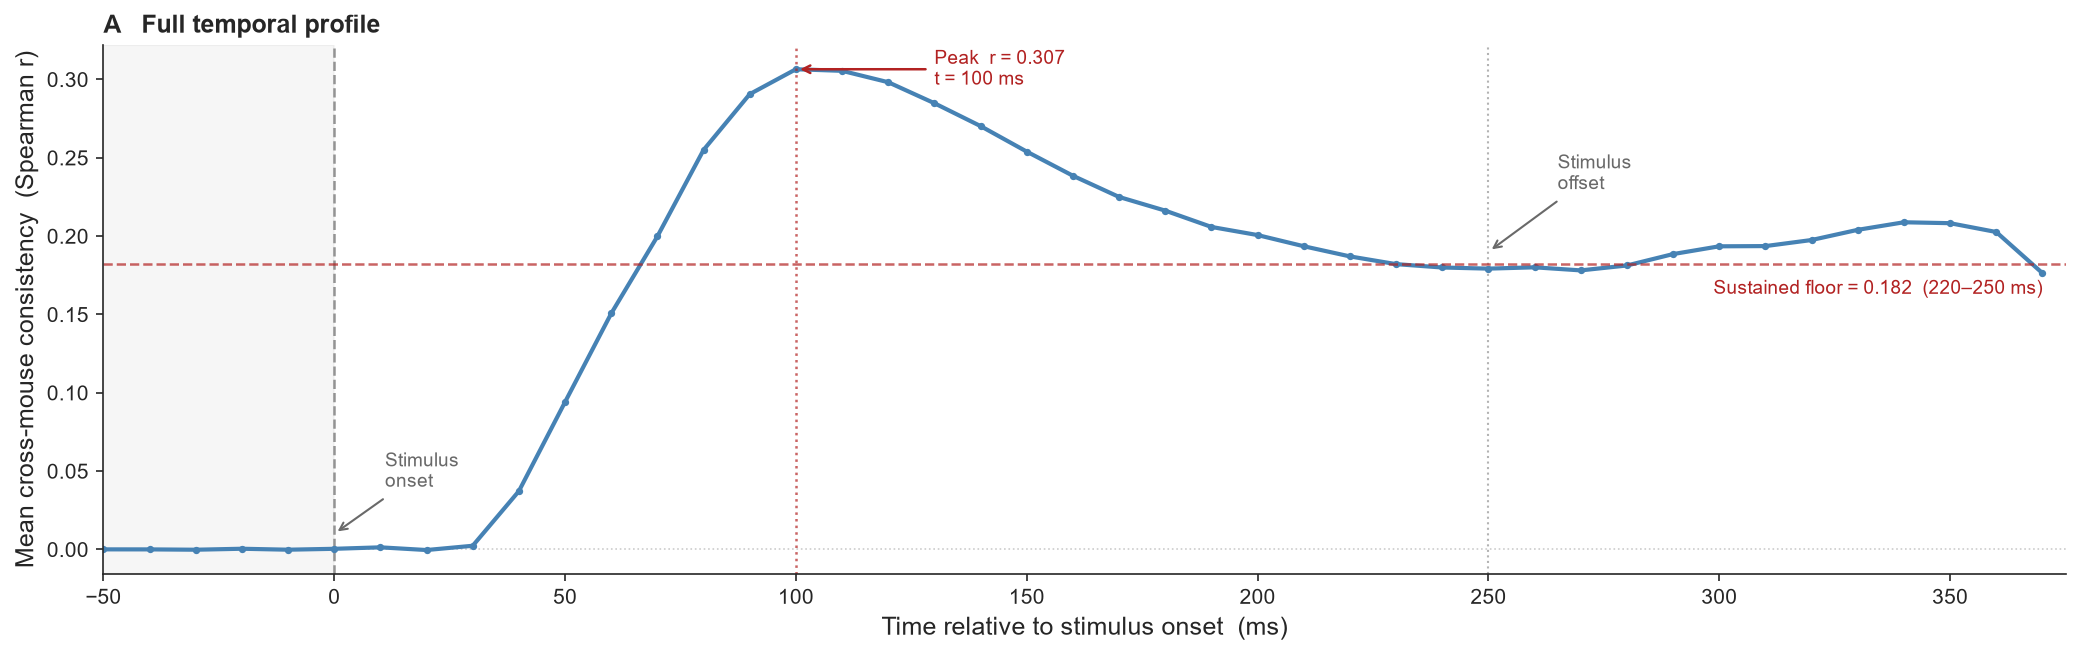

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4.5))

ax = axes

ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.0, alpha=0.5)
ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)
ax.set_xlabel('Time relative to stimulus onset  (ms)')
ax.set_ylabel('Mean cross-mouse consistency  (Spearman r)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
ax.spines[['top', 'right']].set_visible(False)

ax.plot(times_ms, mean_c, color=COL_NS, linewidth=2.0,
        marker='o', markersize=2.5)
ax.axvline(peak_t, color=COL_FIT, linestyle=':', linewidth=1.2, alpha=0.7)
ax.axhline(sustained_floor, color=COL_FIT, linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(SLIDE_END_MS - 5, sustained_floor-0.01,
        f'Sustained floor = {sustained_floor:.3f}  (220–250 ms)',
        color=COL_FIT, fontsize=9, ha='right', va='top')
ax.annotate(f'Peak  r = {peak_c:.3f}\nt = {peak_t} ms',
            xy=(peak_t, peak_c), xytext=(peak_t + 30, peak_c),
            arrowprops=dict(arrowstyle='->', color=COL_FIT, lw=1.2),
            color=COL_FIT, fontsize=9, va='center')
ax.annotate('Stimulus\nonset', xy=(0, 0.01), xytext=(11, 0.04),
            arrowprops=dict(arrowstyle='->', color=COL_REF, lw=1),
            color=COL_REF, fontsize=9)
ax.annotate('Stimulus\noffset',
            xy=(250, 0.19), xytext=(265, 0.23),
            arrowprops=dict(arrowstyle='->', color=COL_REF, lw=1),
            color=COL_REF, fontsize=9)
ax.set_title('A   Full temporal profile', loc='left', fontweight='bold', pad=6)

print_figure_data(
    'Fig. 3 — Full temporal profile',
    time_ms=times_arr,
    mean_cross_mouse_consistency=mean_c,
    peak_time_ms=np.array(peak_t),
    peak_consistency=np.array(peak_c),
    sustained_floor_220_250ms=np.array(sustained_floor),
    baseline_prestimulus=np.array(baseline),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_temporal_profile.png', bbox_inches='tight')
plt.show()


Early vs. late window consistency

--- per_image_early_window_consistency_0_75ms ---
shape=(118,)
[0.064869 0.076667 0.118885 0.060935 0.043681 0.088075 0.124158 0.032385 0.043378 0.048043 0.040167 0.05752  0.117794 0.12958  0.14724  0.054452 0.029314 0.039021 0.186349 0.149428]
...[118 elements total]

--- per_image_late_window_consistency_75_250ms ---
shape=(118,)
[0.424425 0.140098 0.311657 0.420981 0.520625 0.377216 0.42867  0.189129 0.26196  0.223541 0.280232 0.243543 0.304835 0.291174 0.247065 0.393858 0.393426 0.464041 0.305616 0.361311]
...[118 elements total]

--- equal_consistency_reference_line ---
[-0.003109  0.618633]

--- wilcoxon_p_value ---
4.209014223723733e-21

--- image_rank_spearman_r ---
0.36474824610417833


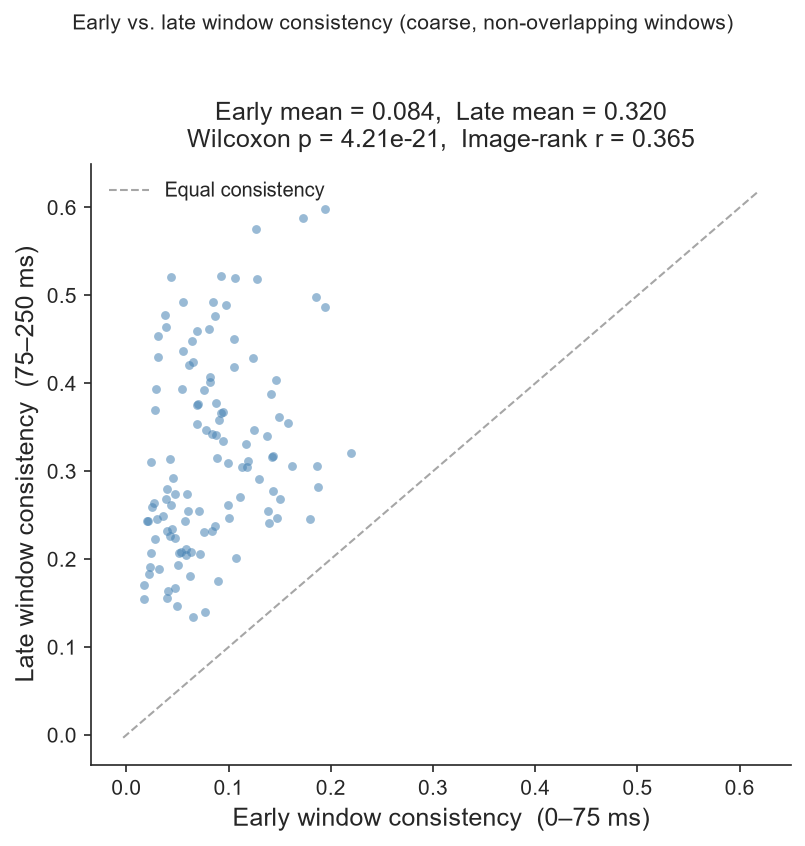

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
lims = [min(c_early.min(), c_late.min()) - 0.02,
        max(c_early.max(), c_late.max()) + 0.02]
ax.scatter(c_early, c_late, s=18, alpha=0.55, color=COL_NS, linewidths=0)
ax.plot(lims, lims, 'k--', alpha=0.35, linewidth=1, label='Equal consistency')
ax.set_xlabel('Early window consistency  (0–75 ms)')
ax.set_ylabel('Late window consistency  (75–250 ms)')
ax.set_title(f'Early mean = {c_early.mean():.3f},  Late mean = {c_late.mean():.3f}\n'
             f'Wilcoxon p = {p_wil:.2e},  Image-rank r = {r_el:.3f}',
             pad=8)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Early vs. late window consistency (coarse, non-overlapping windows)',
             fontsize=10, y=1.02)

print_figure_data(
    'Early vs. late window consistency',
    per_image_early_window_consistency_0_75ms=c_early,
    per_image_late_window_consistency_75_250ms=c_late,
    equal_consistency_reference_line=np.array(lims),
    wilcoxon_p_value=np.array(p_wil),
    image_rank_spearman_r=np.array(r_el),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS3_early_vs_late.png', bbox_inches='tight')
plt.show()


S7A — Rank-correlation matrix across epochs

--- epoch_labels ---
['Pre (−25 ms)', 'Early FF (25 ms)', 'Ramp (50 ms)', 'Peak (100 ms)', 'Decay (175 ms)', 'Sustained (250 ms)']

--- epoch_times_ms ---
[-30  20  50 100 170 250]

--- rank_correlation_matrix ---
shape=(6, 6)
[ 1.       -0.014159 -0.093138  0.102122 -0.077003 -0.055011 -0.014159  1.       -0.024465 -0.099829 -0.045939 -0.103174 -0.093138 -0.024465  1.        0.196615  0.157955  0.230156  0.102122
 -0.099829]
...[36 elements total]

--- rank_correlation_p_values ---
shape=(6, 6)
[0.       0.879048 0.315788 0.271157 0.407218 0.55408  0.879048 0.       0.792575 0.282123 0.621324 0.266226 0.315788 0.792575 0.       0.032849 0.08758  0.012167 0.271157 0.282123]
...[36 elements total]

S7B — Divergence of image ranking from peak window

--- window_centre_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- spearman_r_vs_peak_window ---
shape=(43,)
[ 0.01

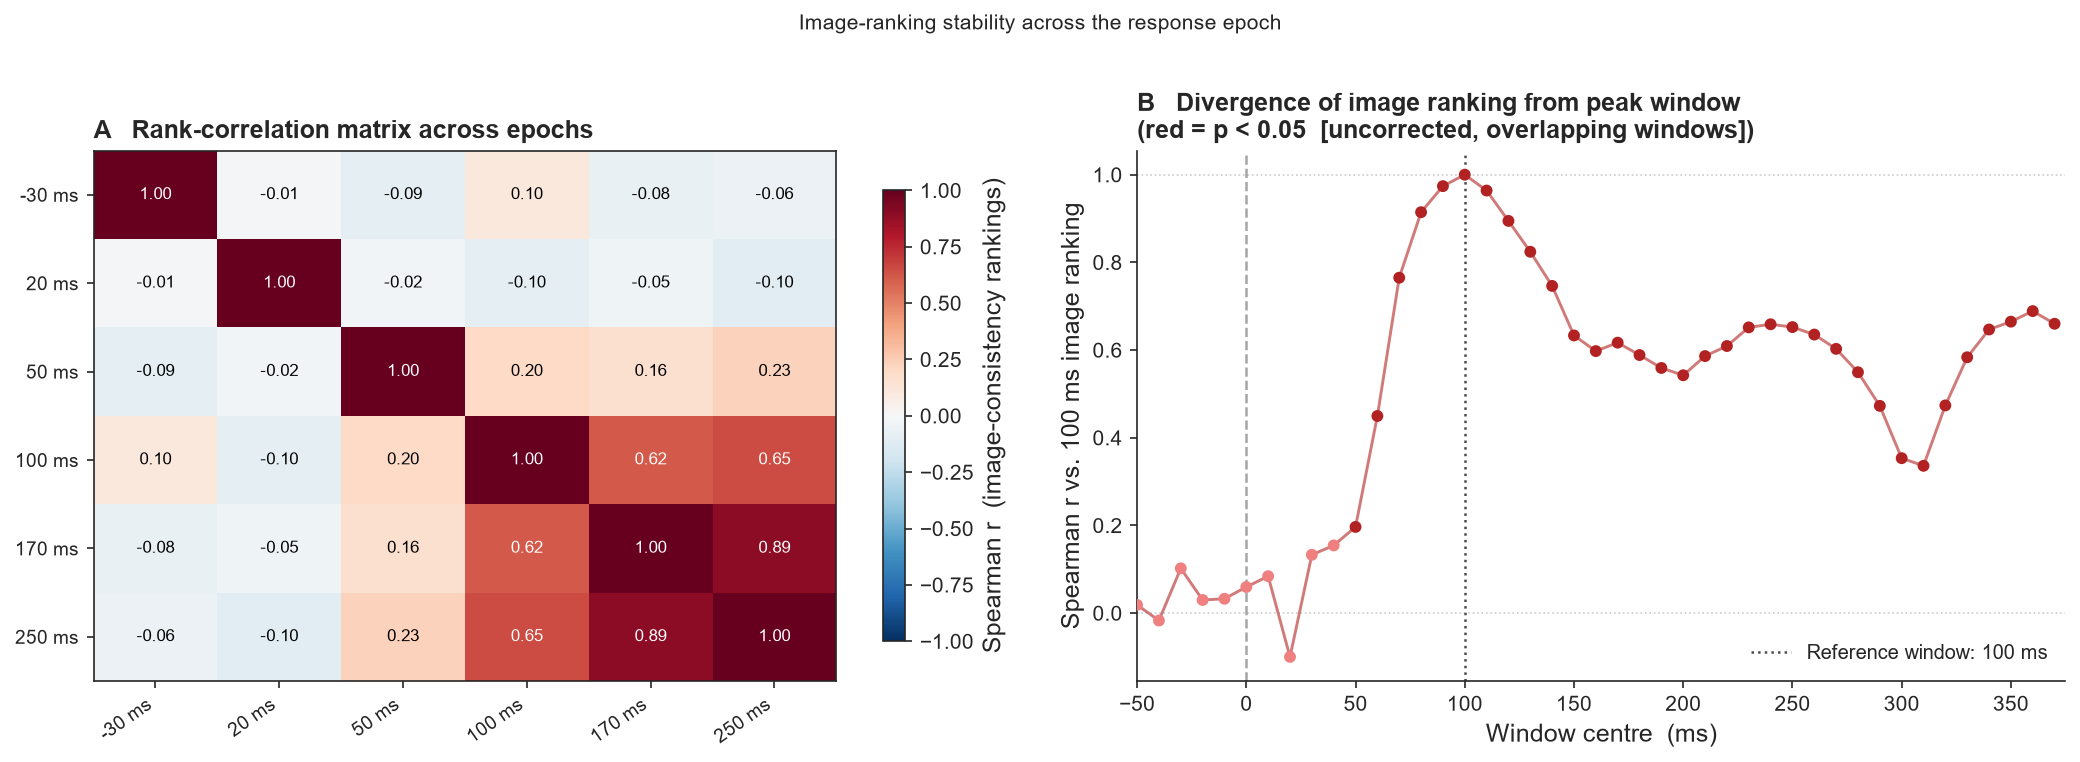

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: rank-correlation matrix
ax = axes[0]
im = ax.imshow(rank_corr, vmin=-1.0, vmax=1.0, cmap='RdBu_r', aspect='auto')
tick_labels = [f'{t} ms' for t in epoch_times]
ax.set_xticks(range(n_epochs));  ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(n_epochs));  ax.set_yticklabels(tick_labels, fontsize=9)
plt.colorbar(im, ax=ax, label='Spearman r  (image-consistency rankings)', shrink=0.85)
for i in range(n_epochs):
    for j in range(n_epochs):
        col = 'white' if abs(rank_corr[i, j]) > 0.6 else 'black'
        ax.text(j, i, f'{rank_corr[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color=col)
ax.set_title('A   Rank-correlation matrix across epochs', loc='left',
             fontweight='bold', pad=6)

# Panel B: rolling correlation vs. peak
ax = axes[1]
sig_col = [COL_FIT if p < 0.05 else 'lightcoral' for p in p_vs_peak]
ax.scatter(times_ms, r_vs_peak, c=sig_col, s=22, zorder=3)
ax.plot(times_ms, r_vs_peak, color=COL_FIT, linewidth=1.4, alpha=0.6)
ax.axvline(0,        color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(peak_key, color='black', linestyle=':',  linewidth=1.2, alpha=0.7,
           label=f'Reference window: {peak_key} ms')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)
ax.axhline(1, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Window centre  (ms)')
ax.set_ylabel(f'Spearman r vs. {peak_key} ms image ranking')
ax.set_title(f'B   Divergence of image ranking from peak window\n'
             '(red = p < 0.05  [uncorrected, overlapping windows])',
             loc='left', fontweight='bold', pad=6)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Image-ranking stability across the response epoch', fontsize=10, y=1.01)

print_figure_data(
    'S7A — Rank-correlation matrix across epochs',
    epoch_labels=epoch_labels,
    epoch_times_ms=np.array(epoch_times),
    rank_correlation_matrix=rank_corr,
    rank_correlation_p_values=rank_p,
)
print_figure_data(
    'S7B — Divergence of image ranking from peak window',
    window_centre_ms=np.array(times_ms),
    spearman_r_vs_peak_window=np.array(r_vs_peak),
    p_value_vs_peak_window=np.array(p_vs_peak),
    peak_reference_window_ms=np.array(peak_key),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS7_rank_stability.png', bbox_inches='tight')
plt.show()


S8A — Distribution of second-order r

--- per_image_second_order_r ---
shape=(118,)
[0.229551 0.098021 0.182822 0.235322 0.301421 0.259438 0.234751 0.11042  0.124609 0.131789 0.134557 0.159553 0.186422 0.16583  0.147061 0.244024 0.212126 0.269375 0.193036 0.227779]
...[118 elements total]

--- mean_second_order_r ---
0.1868564

S8B — Per-window mean second-order r

--- window_labels ---
['pre (-30 ms)', 'early (50 ms)', 'peak (100 ms)', 'decay (170 ms)', 'sustained (250 ms)']

--- per_window_mean_second_order_r ---
[-0.000179  0.094116  0.30653   0.225004  0.179258]

--- per_window_sem_second_order_r ---
[0.000424 0.005176 0.013337 0.007563 0.006048]

S8C — Second-order vs. first-order consistency

--- first_order_consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163267 0.260908 0.19579  0.275605 0.248535 0.290777 0.303716 0.260574 0.379713 0.378248 0.45102  0.32783  0.369047]
...[118 elements total]

--- second_order_r ---
shape=(118,)
[0.

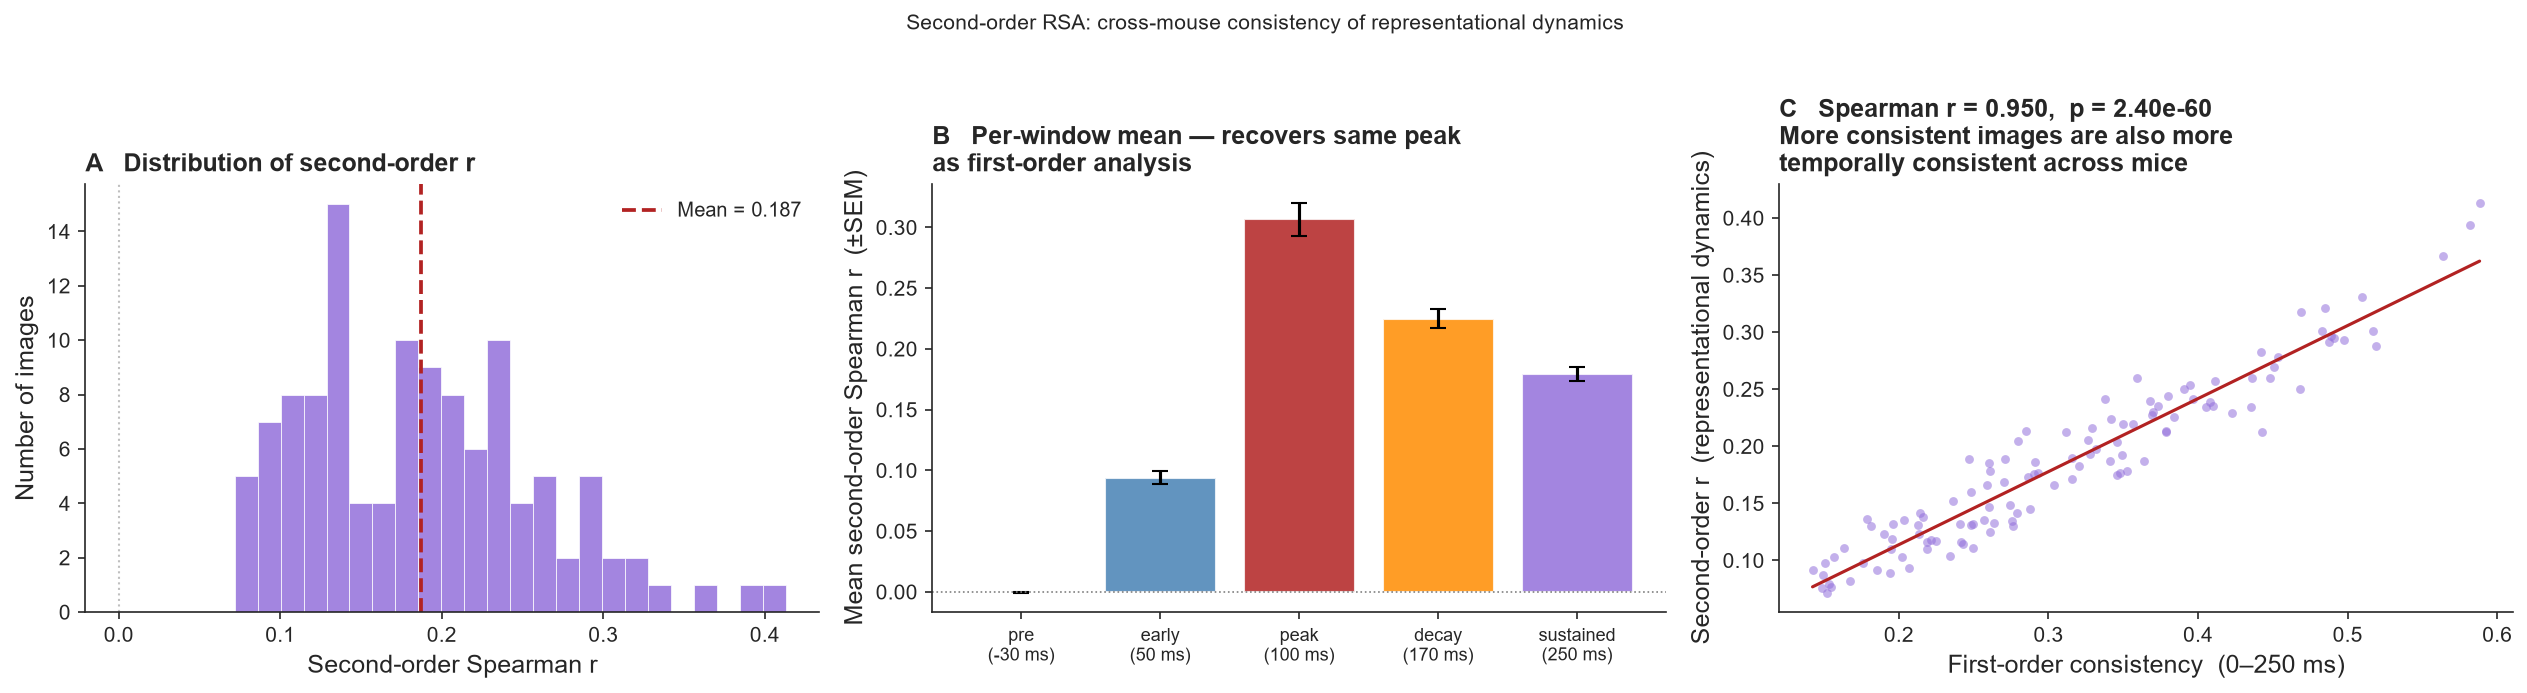

In [17]:
so_window_labels = list(SO_WINDOWS_MS.keys())
per_win_means = [np.nanmean(so_r_by_window[:, w]) for w in range(n_so_windows)]
per_win_sems  = [np.nanstd(so_r_by_window[:, w]) / np.sqrt(N_IMAGES)
                 for w in range(n_so_windows)]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel A: distribution of second-order r
ax = axes[0]
ax.hist(second_order_r, bins=24, color='mediumpurple', alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.axvline(np.nanmean(second_order_r), color=COL_FIT, linestyle='--',
           linewidth=1.8, label=f'Mean = {np.nanmean(second_order_r):.3f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Second-order Spearman r')
ax.set_ylabel('Number of images')
ax.set_title('A   Distribution of second-order r', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: per-window mean
ax = axes[1]
colors_w = ['lightgray', COL_NS, COL_FIT, COL_GR, 'mediumpurple']
ax.bar(range(n_so_windows), per_win_means, yerr=per_win_sems,
       color=colors_w, alpha=0.85, capsize=4)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(n_so_windows))
ax.set_xticklabels([f'{l}\n({t} ms)' for l, t in
                    zip(so_window_labels, so_t_list)], fontsize=8.5)
ax.set_ylabel('Mean second-order Spearman r  (±SEM)')
ax.set_title('B   Per-window mean — recovers same peak\n'
             'as first-order analysis', loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

# Panel C: second-order vs. first-order
ax = axes[2]
ax.scatter(consistency, second_order_r, s=18, alpha=0.55,
           color='mediumpurple', linewidths=0)
m, b = np.polyfit(consistency, second_order_r, 1)
xr   = np.linspace(consistency.min(), consistency.max(), 100)
ax.plot(xr, m * xr + b, color=COL_FIT, linewidth=1.5)
ax.set_xlabel('First-order consistency  (0–250 ms)')
ax.set_ylabel('Second-order r  (representational dynamics)')
ax.set_title(f'C   Spearman r = {r_so_fo:.3f},  p = {p_so_fo:.2e}\n'
             'More consistent images are also more\n'
             'temporally consistent across mice',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Second-order RSA: cross-mouse consistency of representational dynamics',
             fontsize=10, y=1.02)

print_figure_data(
    'S8A — Distribution of second-order r',
    per_image_second_order_r=second_order_r,
    mean_second_order_r=np.array(np.nanmean(second_order_r)),
)
print_figure_data(
    'S8B — Per-window mean second-order r',
    window_labels=[f'{l} ({t} ms)' for l, t in zip(so_window_labels, so_t_list)],
    per_window_mean_second_order_r=np.array(per_win_means),
    per_window_sem_second_order_r=np.array(per_win_sems),
)
print_figure_data(
    'S8C — Second-order vs. first-order consistency',
    first_order_consistency=consistency,
    second_order_r=second_order_r,
    linear_fit_x=xr,
    linear_fit_y=m * xr + b,
    spearman_r_second_vs_first=np.array(r_so_fo),
    p_value_second_vs_first=np.array(p_so_fo),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS8_second_order_rsa.png', bbox_inches='tight')
plt.show()